In [1]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision 
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [2]:
from huggingface_hub import login
login() 

In [3]:
from datasets import load_dataset
# Now you can load your dataset
dataset=  load_dataset("AIOmarRehan/AnimalsDataset")
print("SUCCESS!")
print(dataset)

SUCCESS!
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})


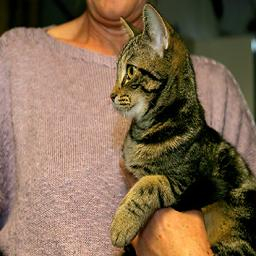

In [4]:

# If it's an image dataset, you can display the image directly in VS Code
dataset['train'][0]['image']

In [5]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 0}

In [6]:
type(dataset)

datasets.dataset_dict.DatasetDict

In [7]:
dir(dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__orig_bases__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_values_features',
 '_check_values_type',
 'align_labels_with_mapping',
 'cache_files',
 'cast',
 'cast_column',
 'class_encode_column',
 'cleanup_cache_files',
 'clear',
 'column_names',
 'copy',
 'data',
 'filter',
 'flatten',
 'flatten_indices',
 'formatted_as',
 'from_csv',
 'from_json',
 'from_parquet',
 'from_text',
 'fromkeys',
 'get',
 'items',
 'keys',
 'load_from_disk',
 'map',
 'nu

In [8]:
dataset.num_columns

{'train': 2}

# 1. Data Integrity & Cleaning (The "Pre-Loop")
Some files might be grayscale, too small, or duplicates.

### a. Filtering by Image Mode (RGB vs. Grayscale)
CNNs like AnimalCNN expect 3 channels (RGB). If a "Black and White" image sneaks in, it might only have 1 channel, which will crash your model during training

In [9]:
# Check for non-RGB images
def filter_rgb(example):
    return example['image'].mode == 'RGB'

# Clean the dataset
dataset = dataset.filter(filter_rgb)

## B. Finding Duplicates (Hashing in Memory)

we hash the pixel data itself to find identical images.

In [10]:
import hashlib

def get_pil_hash(image):
    # Convert image to bytes to create a hash
    return hashlib.md5(image.tobytes()).hexdigest()

# Create a list of hashes to find duplicates
hashes = [get_pil_hash(img) for img in dataset['train']['image']]

# 1. Create a mapping of {hash: index}
# This will keep the FIRST index it sees for every unique hash
unique_hashes = {}
for idx, img in enumerate(dataset['train']['image']):
    h = get_pil_hash(img)
    if h not in unique_hashes:
        unique_hashes[h] = idx

# 2. Extract the list of valid indices
indices_to_keep = [v for v in unique_hashes.values()]

print(f"Original size: {len(dataset['train'])}")
print(f"Cleaned size: {len(indices_to_keep)}")
print(f"Removed {len(dataset['train']) - len(indices_to_keep)} duplicates.")

Original size: 3000
Cleaned size: 2999
Removed 1 duplicates.


In [11]:
img=dataset['train'][1]['image']
hash=get_pil_hash(img)
print(hash)

ba0eeb1f68e62317d90e5cc187724412


Index of the duplicate image: [673]


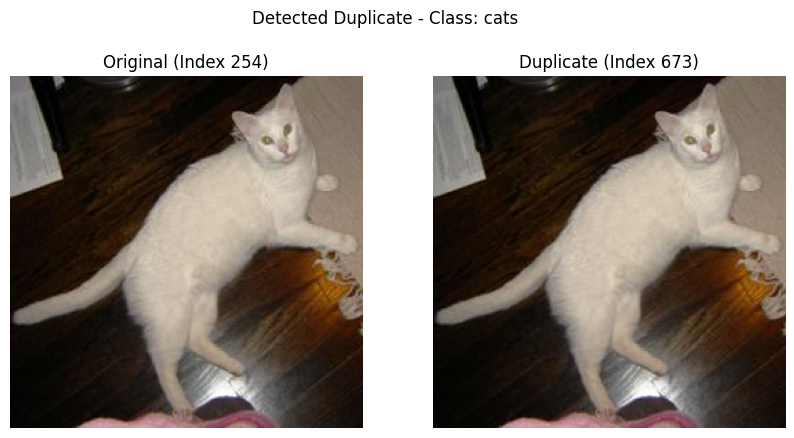

In [12]:
# Create a set of all indices (0 to 2999)
all_indices = set(range(len(dataset['train'])))

# Subtract the indices we kept
duplicate_indices = [*(all_indices - set(indices_to_keep))]
print(f"Index of the duplicate image: {duplicate_indices}")


# Get the first duplicate index found
dup_idx = duplicate_indices[0]
dup_img = dataset['train'][dup_idx]['image']
dup_label = dataset['train'][dup_idx]['label']

# Find where the original is in our 'unique_hashes' dictionary
# (We need to re-calculate the hash for this specific image)
target_hash = get_pil_hash(dup_img)
orig_idx = unique_hashes[target_hash]
orig_img = dataset['train'][orig_idx]['image']

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(orig_img)
axes[0].set_title(f"Original (Index {orig_idx})")
axes[0].axis('off')

axes[1].imshow(dup_img)
axes[1].set_title(f"Duplicate (Index {dup_idx})")
axes[1].axis('off')

plt.suptitle(f"Detected Duplicate - Class: {dataset['train'].features['label'].names[dup_label]}")
plt.show()

In [ ]:
# Create the finalized, unique set
dataset_final = dataset['train'].select(indices_to_keep)

print(f"Final Dataset Ready: {len(dataset_final)} unique samples.")

Final Dataset Ready: 2999 unique samples.


# 2. Exploratory Data Analysis (EDA)
We can extract metadata from the PIL objects to see what our model is about to face.

## A. Class Distribution (The Balance Check)

This is the most important EDA step. If "Snakes" only have 10 images while "Dogs" have 1000, the model will be biased.

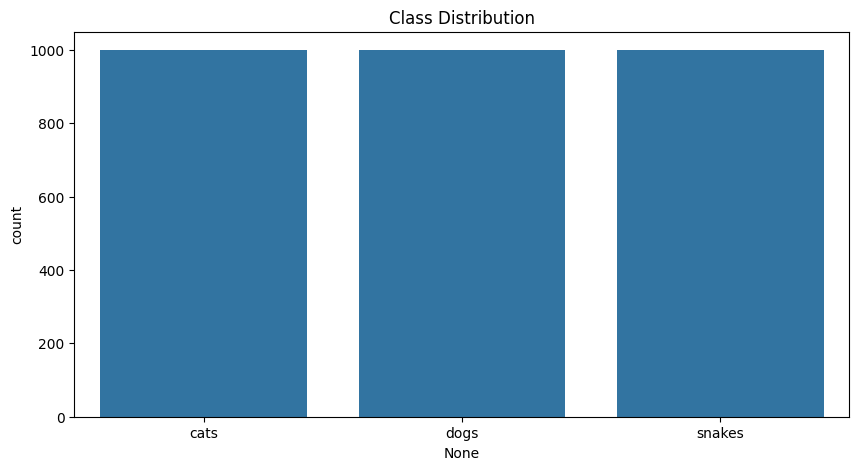

In [ ]:
import pandas as pd
import seaborn as sns

# Convert labels to a Pandas Series for quick plotting
labels = pd.Series(dataset['train']['label'])
label_names = dataset['train'].features['label'].names

plt.figure(figsize=(10, 5))
sns.countplot(x=labels.map(lambda x: label_names[x]))
plt.title("Class Distribution")
plt.show()

## B. Image Size Analysis
Since we are resizing to 256x256, we want to know if we are "upscaling" (stretching small images) or "downscaling" (shrinking large ones). 

Upscaling small images often leads to blurry features and poor accuracy.

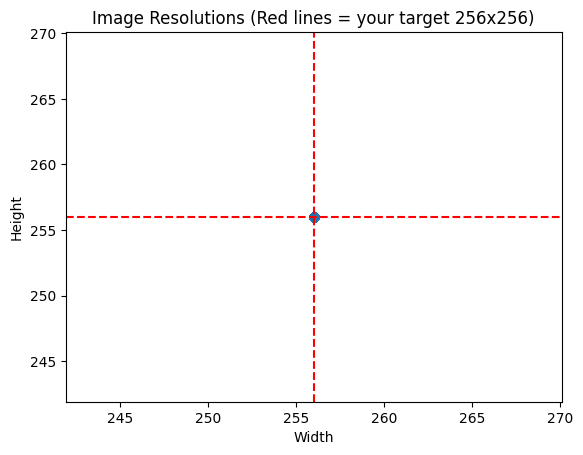

In [14]:
# Get all widths and heights
sizes = [(img.width, img.height) for img in dataset['train']['image']]
widths, heights = zip(*sizes)

plt.scatter(widths, heights, alpha=0.3)
plt.axvline(256, color='r', linestyle='--')
plt.axhline(256, color='r', linestyle='--')
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolutions (Red lines = your target 256x256)")
plt.show()

## C. Brightness & Contrast EDA

If the animal images are very dark, the model might struggle to find edges.

Text(0.5, 1.0, 'Brightness Distribution (0=Black, 255=White)')

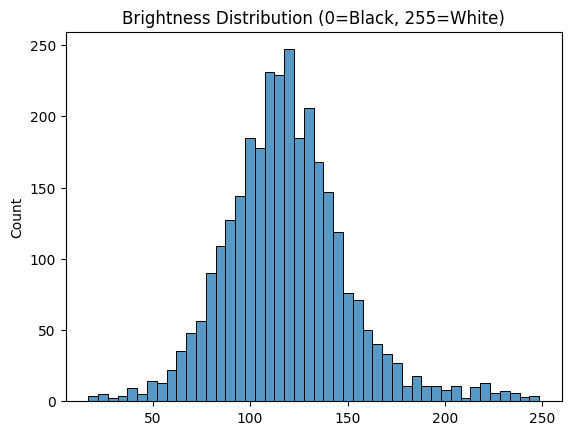

In [15]:
from PIL import ImageStat

def calculate_brightness(image):
    stat = ImageStat.Stat(image.convert("L"))
    return stat.mean[0]

brightness_values = [calculate_brightness(img) for img in dataset['train']['image']]
sns.histplot(brightness_values)
plt.title("Brightness Distribution (0=Black, 255=White)")

In [16]:
class_names = dataset['train'].features['label'].names
# Result: ['Cat', 'Dog', 'Bird', ...]
class_names

['cats', 'dogs', 'snakes']

2


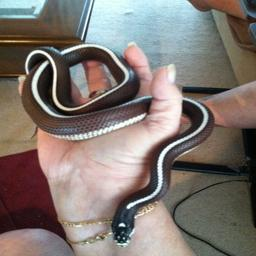

In [18]:
# Let's split our data into training and testing. we will use 2750 for training and 250 for testing

# This shuffles and splits 250 rows (approx 8.3%) into 'test'
split_dict = dataset['train'].select(indices_to_keep).train_test_split(test_size=200, seed=42)

train_dataset = split_dict['train']
test_dataset = split_dict['test']

# Ensure train_dataset is indexable by int (e.g., Dataset type)
assert hasattr(train_dataset, '__getitem__'), "train_dataset must support integer indexing"

random_idx = torch.randint(0, len(train_dataset), size=[1]).item()
sample = train_dataset[random_idx] # type: ignore # Get the full sample dict
img, label = sample['image'], sample['label']
print(label)
img  # Display image


In [19]:
split_dict

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2799
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
})

In [20]:
test_dataset[5]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 2}

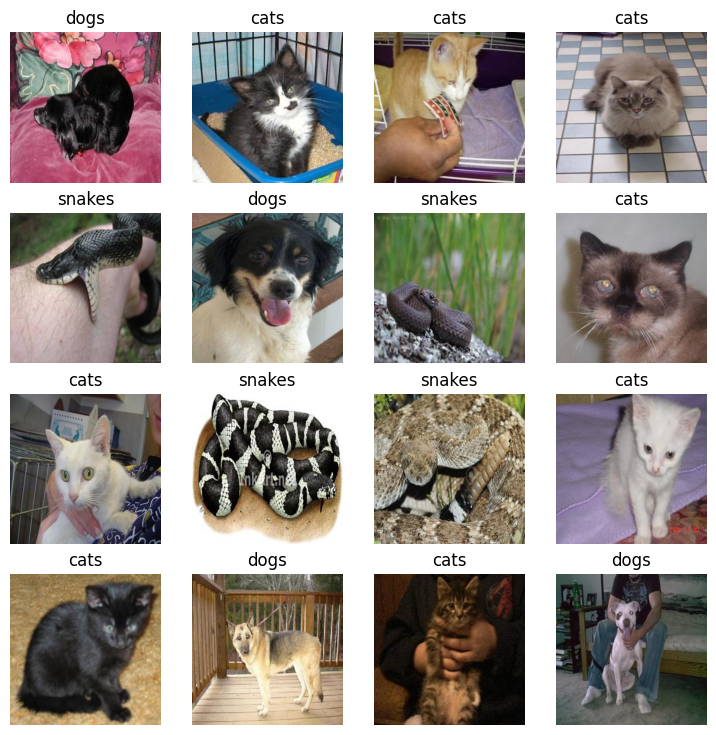

In [21]:
import numpy as np

# Plot more images
#torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_dataset), size=[1]).item() # get a random index and convert to Python int
    sample = train_dataset[random_idx] # type: ignore
    img, label = sample['image'], sample['label'] 
    
    image_class=class_names[label]
    # Turn the image into an array
    img_as_array = np.asarray(img) 
    # Plot the images with matplotlib 
    fig.add_subplot(rows, cols, i)
    plt.imshow(img_as_array)
    plt.title(class_names[label])
    plt.axis(False)


###  Transforming data with `torchvision.transforms`

We've got folders of images but before we can use them with PyTorch, we need to convert them into tensors.

One of the ways we can do this is by using the `torchvision.transforms` module.

`torchvision.transforms` contains many pre-built methods for formatting images, turning them into tensors and even manipulating them 

for **data augmentation** (the practice of altering data to make it harder for a model to learn. 

To get experience with `torchvision.transforms`, let's write a series of transform steps that:
1. Resize the images using [`transforms.Resize()`]
2. Flip our images randomly on the horizontal using [`transforms.RandomHorizontalFlip()`]
3. Turn our images from a PIL image to a PyTorch tensor using [`transforms.ToTensor()`]

We can compile all of these steps using [`torchvision.transforms.Compose()`]

In [22]:
from torchvision import transforms


# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

Now we've got a composition of transforms, let's write a function to try them out on various images.

In [23]:
# Shuffles indices only (very fast) and picks the first 5
random_samples = train_dataset.shuffle(seed=42).select(range(5))

# You can then loop through them
for example in random_samples:
    print(example['label']) # type: ignore

1
0
2
0
2


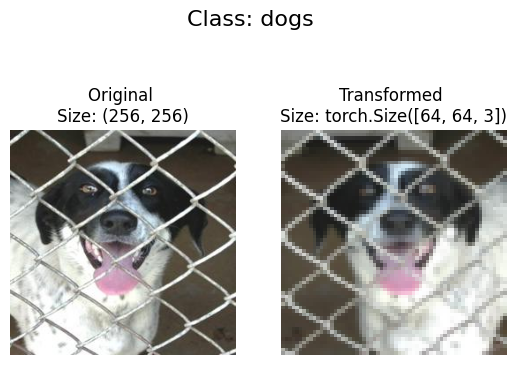

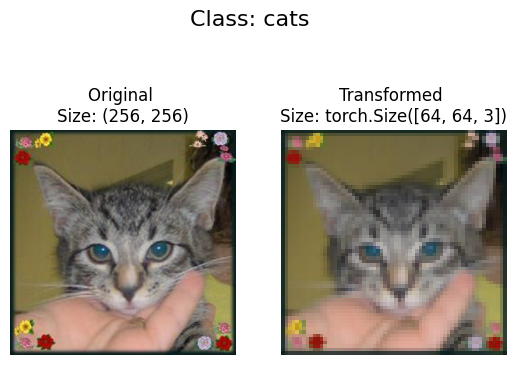

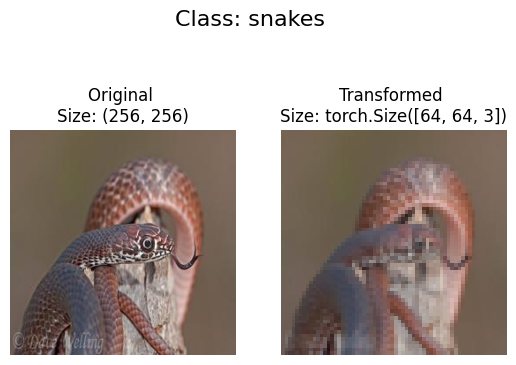

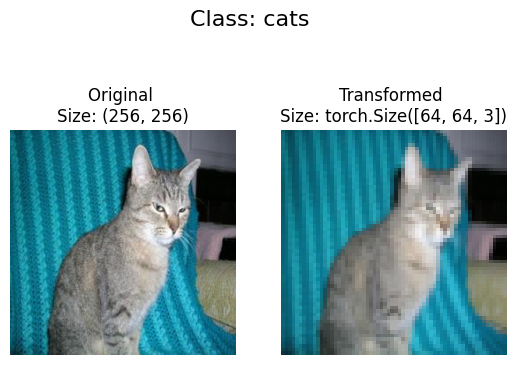

In [24]:
import random

def plot_transformed_images(transform, n=3, seed=42):
    random.seed(seed)
    # Shuffles indices only  and picks the first 5
    random_samples = train_dataset.shuffle(seed=42).select(range(n))
    for example in random_samples:
        img,label = example['image'], example['label'] # type:ignore
        image_class=class_names[label]
        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(img) 
        ax[0].set_title(f"Original \nSize: {img.size}")
        ax[0].axis("off")

        # Transform and plot image
        # Note: permute() will change shape of image to suit matplotlib 
        # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
        transformed_image = transform(img).permute(1, 2, 0) 
        ax[1].imshow(transformed_image) 
        ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
        ax[1].axis("off")

        fig.suptitle(f"Class: {image_class}", fontsize=16)

plot_transformed_images(transform=data_transform, 
                        n=4)

Nice!

We've now got a way to convert our images to tensors using `torchvision.transforms`.

We also manipulate their size and orientation if needed (some models prefer images of different sizes and shapes).

Generally, the larger the shape of the image, the more information a model can recover.

For example, an image of size `[256, 256, 3]` will have 16x more pixels than an image of size `[64, 64, 3]` (`(256*256*3)/(64*64*3)=16`).

However, the tradeoff is that more pixels requires more computations.


In [25]:
#Now transform the whole dataset into tensor

# Define a wrapper function for your transforms
def apply_transforms_64(examples):
    # Apply transforms to every image in the batch
    examples["pixel_values"] = [data_transform(image.convert("RGB")) for image in examples["image"]]
    return examples

# Apply it to your datasets
train_data = train_dataset.with_transform(apply_transforms_64)
test_data = test_dataset.with_transform(apply_transforms_64)

# Now when you access an item, it is transformed on-the-fly
print(train_data[0].keys()) 
# Should show 'pixel_values' (your transformed tensor)

dict_keys(['image', 'label', 'pixel_values'])


In [26]:
train_data

Dataset({
    features: ['image', 'label'],
    num_rows: 2799
})

In [27]:
train_data[6]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 1,
 'pixel_values': tensor([[[0.2431, 0.2392, 0.1961,  ..., 0.5255, 0.6118, 0.6039],
          [0.2667, 0.2510, 0.2039,  ..., 0.4392, 0.6235, 0.6510],
          [0.2667, 0.2275, 0.2157,  ..., 0.3765, 0.5373, 0.7451],
          ...,
          [0.4824, 0.7059, 0.8549,  ..., 0.6667, 0.7529, 0.6078],
          [0.3216, 0.3922, 0.6078,  ..., 0.6627, 0.7961, 0.6196],
          [0.3529, 0.3412, 0.3569,  ..., 0.7059, 0.7882, 0.6314]],
 
         [[0.2353, 0.2275, 0.1843,  ..., 0.4824, 0.5451, 0.5333],
          [0.2588, 0.2392, 0.1922,  ..., 0.4039, 0.5647, 0.5843],
          [0.2588, 0.2196, 0.2039,  ..., 0.3569, 0.4941, 0.6784],
          ...,
          [0.4706, 0.6941, 0.8431,  ..., 0.5765, 0.6510, 0.4392],
          [0.3098, 0.3804, 0.5961,  ..., 0.5686, 0.6784, 0.4471],
          [0.3412, 0.3255, 0.3412,  ..., 0.6275, 0.6784, 0.4784]],
 
         [[0.1843, 0.1804, 0.1490,  ..., 0.3725, 0.4392, 0.4471],
  

In [28]:
test_data[9]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 1,
 'pixel_values': tensor([[[0.2627, 0.2510, 0.2471,  ..., 0.1020, 0.1020, 0.0941],
          [0.2745, 0.2745, 0.2745,  ..., 0.0980, 0.0980, 0.0980],
          [0.2863, 0.2824, 0.2784,  ..., 0.1098, 0.1059, 0.1137],
          ...,
          [0.2863, 0.2941, 0.3020,  ..., 0.4667, 0.3569, 0.3490],
          [0.2863, 0.2902, 0.2784,  ..., 0.3922, 0.4510, 0.4588],
          [0.2863, 0.2824, 0.2784,  ..., 0.4235, 0.5647, 0.5451]],
 
         [[0.2275, 0.2196, 0.2157,  ..., 0.1333, 0.1333, 0.1255],
          [0.2471, 0.2431, 0.2471,  ..., 0.1294, 0.1333, 0.1333],
          [0.2627, 0.2588, 0.2588,  ..., 0.1451, 0.1412, 0.1451],
          ...,
          [0.3882, 0.3961, 0.4039,  ..., 0.4000, 0.3216, 0.3451],
          [0.3882, 0.3922, 0.3804,  ..., 0.3451, 0.4392, 0.4902],
          [0.3882, 0.3843, 0.3804,  ..., 0.4039, 0.5373, 0.5412]],
 
         [[0.1686, 0.1608, 0.1569,  ..., 0.0824, 0.0824, 0.0706],
  

# DataLoader( with the custom collate function )
Hugging Face datasets return a dictionary (e.g., {'image': ..., 'label': ...}). 

PyTorch's default DataLoader expects a tuple of (image, label). We use a "collate" function to glue them together into tensors.

In [29]:
from torch.utils.data import DataLoader

def collate_fn(examples):
    # Stack all images into one big 4D tensor [Batch, Channel, Height, Width]
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    
    # Turn labels into a long tensor
    labels = torch.tensor([example["label"] for example in examples])
    
    return {"pixel_values": pixel_values, "labels": labels}

# 2. Create the DataLoaders
train_dataloader = DataLoader(
    train_data, 
    shuffle=True, 
    collate_fn=collate_fn, 
    batch_size=32
)

test_dataloader = DataLoader(
    test_data, 
    collate_fn=collate_fn, 
    batch_size=32
)

In [30]:
train_dataloader

In [31]:
train_dataloader.__len__()

88

In [32]:
86*32

2752

In [33]:
# Grab one batch
batch = next(iter(train_dataloader))

print(f"Batch Image Shape: {batch['pixel_values'].shape}") 
# Should be [32, 3, Height, Width]

print(f"Batch Label Shape: {batch['labels'].shape}")     
# Should be [32]

Batch Image Shape: torch.Size([32, 3, 64, 64])
Batch Label Shape: torch.Size([32])


In [34]:
batch['labels']

tensor([2, 2, 0, 1, 1, 0, 1, 2, 0, 2, 0, 1, 0, 2, 2, 0, 2, 1, 1, 0, 1, 2, 2, 2,
        0, 0, 0, 1, 2, 1, 1, 2])

In [35]:
dir(enumerate(train_dataloader))

['__class__',
 '__class_getitem__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__']

In [36]:
dir(batch)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [37]:
batch.__class__

dict

In [38]:
batch['pixel_values'][0]

tensor([[[0.6627, 0.6353, 0.6157,  ..., 0.2039, 0.2039, 0.2078],
         [0.6510, 0.6275, 0.6078,  ..., 0.2078, 0.2118, 0.2118],
         [0.6510, 0.6235, 0.6078,  ..., 0.2157, 0.2157, 0.2078],
         ...,
         [0.5529, 0.5451, 0.5412,  ..., 0.1294, 0.1412, 0.1725],
         [0.5333, 0.5294, 0.5333,  ..., 0.1216, 0.1176, 0.1255],
         [0.5020, 0.4980, 0.4980,  ..., 0.1686, 0.1569, 0.1765]],

        [[0.6980, 0.6706, 0.6510,  ..., 0.2510, 0.2510, 0.2549],
         [0.6863, 0.6627, 0.6392,  ..., 0.2549, 0.2588, 0.2588],
         [0.6824, 0.6549, 0.6353,  ..., 0.2627, 0.2627, 0.2549],
         ...,
         [0.5137, 0.5059, 0.5020,  ..., 0.0863, 0.0941, 0.1020],
         [0.4941, 0.4941, 0.4941,  ..., 0.0745, 0.0706, 0.0667],
         [0.4667, 0.4627, 0.4627,  ..., 0.1020, 0.1020, 0.1059]],

        [[0.6824, 0.6627, 0.6510,  ..., 0.2510, 0.2510, 0.2549],
         [0.6784, 0.6627, 0.6471,  ..., 0.2549, 0.2588, 0.2588],
         [0.6824, 0.6627, 0.6549,  ..., 0.2627, 0.2627, 0.

Now that we have the dataLoader, let's build the model

In [39]:
class TinyVGG(nn.Module):
   
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(class_names))#.to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [40]:
list=[[2,3],[4,5],[6,7],[8,9],[1,4],[2,6]]
for idx, A in enumerate(list):
    print (A)

[2, 3]
[4, 5]
[6, 7]
[8, 9]
[1, 4]
[2, 6]


In [41]:
list=[[[2,3,4,5,6,7],[8,9,1,4,2,6]]]
for idx, (A,B) in enumerate(list):
    print (A,B)

[2, 3, 4, 5, 6, 7] [8, 9, 1, 4, 2, 6]


In [42]:
def train_step(model: torch.nn.Module, 
               train_dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch_idx, batch_data in enumerate(train_dataloader):
    # Move both to GPU/CPU at once
        X = batch_data['pixel_values']#.to(device)
        y = batch_data['labels']#.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(train_dataloader)
    train_acc = train_acc / len(train_dataloader)
    return train_loss, train_acc

In [43]:
def test_step(model: torch.nn.Module, 
              test_dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch_idx, batch_data in enumerate(test_dataloader):
        # Move both to GPU/CPU at once
            X = batch_data['pixel_values']#.to(device)
            y = batch_data['labels']#.to(device)
        
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)
    return test_loss, test_acc

In [44]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           train_dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            test_dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [45]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_1
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0971 | train_acc: 0.3832 | test_loss: 1.0874 | test_acc: 0.4241
Epoch: 2 | train_loss: 1.0500 | train_acc: 0.4540 | test_loss: 1.1277 | test_acc: 0.3750
Epoch: 3 | train_loss: 1.0150 | train_acc: 0.4810 | test_loss: 0.9950 | test_acc: 0.4732
Epoch: 4 | train_loss: 0.9555 | train_acc: 0.5153 | test_loss: 0.8910 | test_acc: 0.5670
Epoch: 5 | train_loss: 0.8797 | train_acc: 0.5796 | test_loss: 0.8734 | test_acc: 0.5759
Total training time: 30.344 seconds


In [46]:
from typing import List
def pred_and_plot_image(model: torch.nn.Module, 
                        target_image, 
                        class_names, 
                        transform=None):
    """Makes a prediction on a target image and plots the image with its prediction."""
    
    # 1. Transform if necessary
    if transform:
        target_image = transform(target_image)
    
    # 2. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)
    
        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image)
        
    # 3. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 4. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1).item() 
       
    # 5. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}"
    else: 
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max():.3f}"
    plt.title(title)
    plt.axis(False)

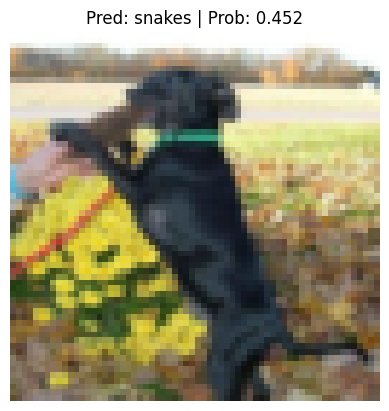

In [47]:
# Pred on a random custom image
random_idx = torch.randint(0, len(test_data), size=[1]).item() # get a random index and convert to Python int
sample = test_data[random_idx] # type: ignore
img, label = sample['image'], sample['label'] 

pred_and_plot_image(model=model_0,
                    target_image=img,
                    class_names=class_names,
                    transform=data_transform)

In [48]:
# Write transform for image
data_transform_256 = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Zoom in on features
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [49]:
class TinyVGG_V2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # --- THE MAGIC ADDITION ---
        # No matter the input size, this forces the feature map to 7x7
        self.adaptive_pool = nn.AdaptiveAvgPool2d(output_size=(7, 7))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Now the math is ALWAYS hidden_units * 7 * 7
            nn.Linear(in_features=hidden_units * 7 * 7, 
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.adaptive_pool(x) # Apply adaptive pooling before flattening
        x = self.classifier(x)
        return x
    
model_1=TinyVGG_V2(input_shape=3,
                   hidden_units=20,
                   output_shape=len(class_names))

In [52]:
# Define a wrapper function for your transforms
def apply_transforms_256(examples):
    # Apply transforms to every image in the batch
    examples["pixel_values"] = [data_transform_256(image.convert("RGB")) for image in examples["image"]]
    return examples

# Apply it to your datasets
train_data_256 = train_dataset.with_transform(apply_transforms_256)
test_data_256 = test_dataset.with_transform(apply_transforms_256)

# Now when you access an item, it is transformed on-the-fly
print(train_data_256[0].keys()) 
# Should show 'pixel_values' (your transformed tensor)

dict_keys(['image', 'label', 'pixel_values'])


In [53]:
train_data_256[0]['pixel_values'].size()

torch.Size([3, 224, 224])

In [ ]:
# 2. Create the new DataLoaders with the 256 (the dataloader only keeps the numbers. it got rid of the PIL images)
train_dataloader_256 = DataLoader(
    train_data_256, 
    shuffle=True, 
    collate_fn=collate_fn, 
    batch_size=32
)

test_dataloader_256 = DataLoader(
    test_data_256, 
    collate_fn=collate_fn, 
    batch_size=32
)

In [91]:
next(iter(train_dataloader_256))

{'pixel_values': tensor([[[[-0.0116, -0.0287, -0.0458,  ...,  0.7419,  0.7419,  0.7419],
           [-0.0458, -0.0458, -0.0629,  ...,  0.7762,  0.7762,  0.7762],
           [-0.0801, -0.0801, -0.0801,  ...,  0.7762,  0.7762,  0.7762],
           ...,
           [ 0.0227,  0.0227,  0.0056,  ..., -0.1486, -0.1828, -0.1828],
           [ 0.0056,  0.0227,  0.0056,  ..., -0.1828, -0.1828, -0.1314],
           [ 0.0056,  0.0227, -0.0116,  ..., -0.1828, -0.1657, -0.1486]],
 
          [[ 0.1352,  0.1176,  0.1001,  ...,  1.0105,  1.0105,  1.0105],
           [ 0.1001,  0.1001,  0.0826,  ...,  1.0105,  1.0105,  0.9930],
           [ 0.0651,  0.0651,  0.0651,  ...,  1.0105,  1.0105,  0.9930],
           ...,
           [ 0.2402,  0.2402,  0.2227,  ..., -0.3550, -0.3725, -0.3725],
           [ 0.2227,  0.2402,  0.2227,  ..., -0.3375, -0.3375, -0.3200],
           [ 0.2227,  0.2402,  0.2052,  ..., -0.3375, -0.3200, -0.3025]],
 
          [[ 0.2348,  0.2173,  0.2173,  ...,  1.2108,  1.2108,  1.2108

In [56]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_1
model_1_results = train(model=model_1, 
                        train_dataloader=train_dataloader_256,
                        test_dataloader=test_dataloader_256,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0173 | train_acc: 0.4553 | test_loss: 0.8979 | test_acc: 0.5804
Epoch: 2 | train_loss: 0.8412 | train_acc: 0.5923 | test_loss: 0.7955 | test_acc: 0.6161
Epoch: 3 | train_loss: 0.7978 | train_acc: 0.6170 | test_loss: 0.7122 | test_acc: 0.6652
Epoch: 4 | train_loss: 0.7846 | train_acc: 0.6205 | test_loss: 0.7047 | test_acc: 0.6384
Epoch: 5 | train_loss: 0.7191 | train_acc: 0.6567 | test_loss: 0.6579 | test_acc: 0.6429
Epoch: 6 | train_loss: 0.7250 | train_acc: 0.6544 | test_loss: 0.6996 | test_acc: 0.6339
Epoch: 7 | train_loss: 0.6932 | train_acc: 0.6652 | test_loss: 0.6339 | test_acc: 0.6920
Epoch: 8 | train_loss: 0.6800 | train_acc: 0.6847 | test_loss: 0.6984 | test_acc: 0.6384
Epoch: 9 | train_loss: 0.6663 | train_acc: 0.6948 | test_loss: 0.6081 | test_acc: 0.6875
Epoch: 10 | train_loss: 0.6224 | train_acc: 0.7054 | test_loss: 0.7135 | test_acc: 0.6652
Total training time: 983.052 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..1.9383754].


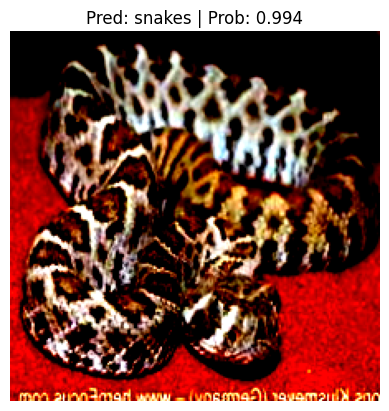

In [ ]:
# Pred on a random custom image
random_idx = torch.randint(0, len(test_data_256), size=[1]).item() # get a random index and convert to Python int
sample = test_data_256[random_idx] # type: ignore
img, label = sample['image'], sample['label'] 

pred_and_plot_image(model=model_1,
                    target_image=img,
                    class_names=class_names,
                    transform=data_transform_256)

In [64]:
random_idx = torch.randint(0, len(test_data_256), size=[9]).tolist()
random_idx

[16, 176, 168, 86, 19, 154, 18, 159, 30]

In [66]:
samples = test_data_256[random_idx] # type: ignore
samples['image']

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>]

In [72]:
def make_predictions(model: torch.nn.Module, 
                     data,
                     transform=None,
                     device="cpu"): # Add device support
    pred_probs = []
    model.to(device)
    model.eval()
    
    with torch.inference_mode():
        for example in data:
            # 1. Transform if necessary
            target_image = example
            if transform:
                target_image = transform(example)
            
            # 2. Add batch dimension and move to device
            target_image = target_image.unsqueeze(dim=0).to(device)
        
            # 3. Forward pass (Logits)
            target_image_pred = model(target_image)
        
            # 4. Logits -> Probabilities
            target_image_pred_prob = torch.softmax(target_image_pred, dim=1)

            # 5. Append to list (Move back to CPU for stacking)
            pred_probs.append(target_image_pred_prob.cpu())
            
    # Stack the list of [1, num_classes] tensors into one [N, num_classes] tensor
    return torch.stack(pred_probs).squeeze()

In [76]:
# Ensure random_idx is used correctly
random_idx = torch.randint(0, len(test_data_256), size=[9]).tolist()

samples = test_data_256.select(random_idx)
imgs = samples['image']   # This is now a LIST of 9 PIL images
labels = samples['label'] # This is a LIST of 9 integers

# Call the function
device = "cuda" if torch.cuda.is_available() else "cpu"
pred_probs = make_predictions(model=model_1,
                              data=imgs,
                              transform=data_transform_256,
                              device=device)

# Get the final labels
pred_labels = pred_probs.argmax(dim=1)
print(f"Predicted: {pred_labels}")
print(f"Actual: {labels}")

Predicted: tensor([1, 1, 2, 1, 1, 0, 0, 0, 2])
Actual: Column([0, 1, 1, 1, 1, ...])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5699118..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8208281].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.8731157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..1.019

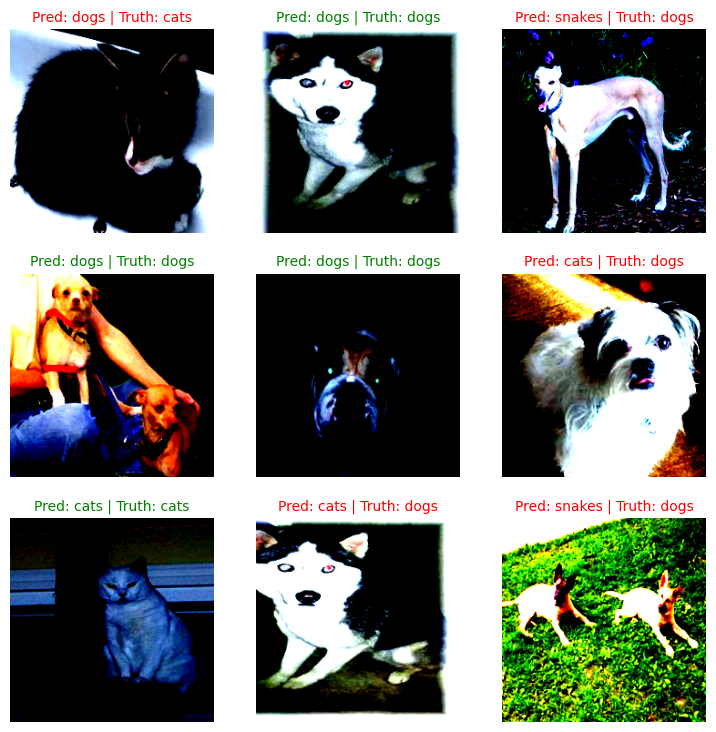

In [77]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, img in enumerate(imgs):
    target_image=data_transform_256(img)
    # Create a subplot
    plt.subplot(nrows, ncols, i+1)
  # 5. Plot the image
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib

    # Find the prediction label (in text form, e.g. "Cats")
    pred_label = class_names[pred_labels[i]]

    # Get the truth label (in text form, e.g. "Dogs")
    truth_label = class_names[labels[i]] 

    # Create the title text of the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    
    # Check for equality and change title colour accordingly
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g") # green text if correct
    else:
        plt.title(title_text, fontsize=10, c="r") # red text if wrong
    plt.axis(False)

We can see that there are still lots of red

## Keep improving

In [80]:
class AnimalCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Block 1
        self.block1 = self._make_block(3, 32, dropout=0.2)
        # Block 2
        self.block2 = self._make_block(32, 64, dropout=0.3)
        # Block 3
        self.block3 = self._make_block(64, 128, dropout=0.4)
        # Block 4
        self.block4 = self._make_block(128, 256, dropout=0.5)
        
        self.pool = nn.AdaptiveAvgPool2d((7, 7)) # Makes it 256x256 ready
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, num_classes)
        )

    def _make_block(self, in_c, out_c, dropout):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.classifier(self.pool(self.block4(self.block3(self.block2(self.block1(x))))))
    
model_2 = AnimalCNN(num_classes=3).to(device)

In [81]:
# Set random seeds
#torch.manual_seed(42) 
#torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_2
model_2_results = train(model=model_2, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.6376 | train_acc: 0.5031 | test_loss: 0.7856 | test_acc: 0.6741
Epoch: 2 | train_loss: 1.0323 | train_acc: 0.5770 | test_loss: 0.8475 | test_acc: 0.6652
Epoch: 3 | train_loss: 0.9492 | train_acc: 0.5955 | test_loss: 1.0561 | test_acc: 0.5670
Epoch: 4 | train_loss: 0.7993 | train_acc: 0.6340 | test_loss: 0.9806 | test_acc: 0.5759
Epoch: 5 | train_loss: 0.8066 | train_acc: 0.6435 | test_loss: 0.9847 | test_acc: 0.5759
Epoch: 6 | train_loss: 0.8213 | train_acc: 0.6398 | test_loss: 0.8130 | test_acc: 0.6250
Epoch: 7 | train_loss: 0.7965 | train_acc: 0.6587 | test_loss: 0.6854 | test_acc: 0.6161
Epoch: 8 | train_loss: 0.7013 | train_acc: 0.6741 | test_loss: 0.6492 | test_acc: 0.7054
Epoch: 9 | train_loss: 0.7618 | train_acc: 0.6646 | test_loss: 0.6138 | test_acc: 0.7232
Epoch: 10 | train_loss: 0.6892 | train_acc: 0.6890 | test_loss: 0.6028 | test_acc: 0.7321
Total training time: 1398.834 seconds


# Make prediction with model 2

In [85]:
# Ensure random_idx is used correctly
random_idx = torch.randint(0, len(test_data_256), size=[9]).tolist()

samples = test_data_256.select(random_idx)
imgs = samples['image']   
labels = samples['label'] 

# Call the function
device = "cuda" if torch.cuda.is_available() else "cpu"
pred_probs = make_predictions(model=model_2,
                              data=imgs,
                              transform=data_transform_256,
                              device=device)

# Get the final labels
pred_labels = pred_probs.argmax(dim=1)
print(f"Predicted: {pred_labels}")
print(f"Actual: {labels}")

Predicted: tensor([0, 0, 0, 2, 1, 0, 0, 2, 0])
Actual: Column([0, 1, 0, 2, 1, ...])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7172985..1.907974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.454815].
Cli

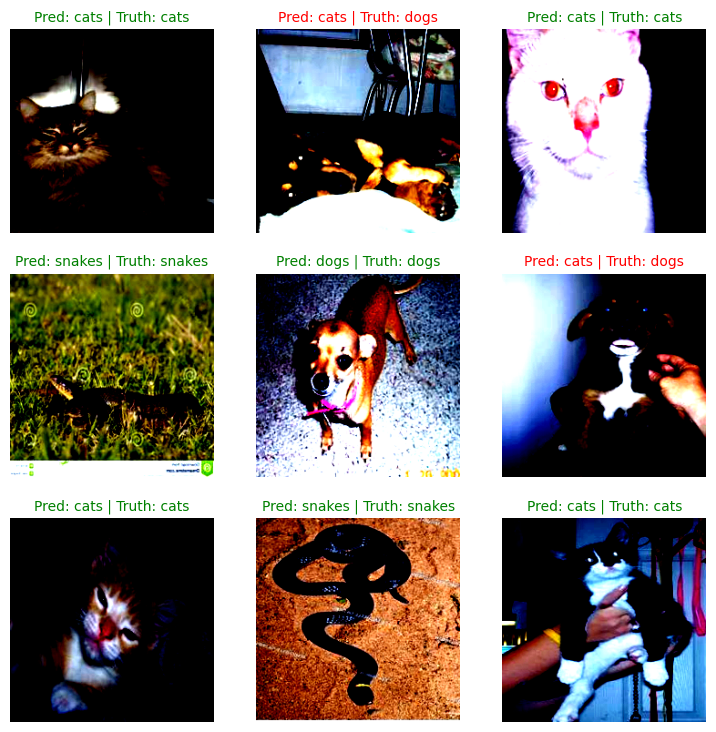

In [86]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, img in enumerate(imgs):
    target_image=data_transform_256(img)
    # Create a subplot
    plt.subplot(nrows, ncols, i+1)
  # 5. Plot the image
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib

    # Find the prediction label (in text form, e.g. "Cats")
    pred_label = class_names[pred_labels[i]]

    # Get the truth label (in text form, e.g. "Dogs")
    truth_label = class_names[labels[i]] 

    # Create the title text of the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    
    # Check for equality and change title colour accordingly
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g") # green text if correct
    else:
        plt.title(title_text, fontsize=10, c="r") # red text if wrong
    plt.axis(False)

## Evaluation metric

In [90]:
next(iter(test_dataloader_256))

{'pixel_values': tensor([[[[ 0.7933,  0.7077,  0.6049,  ..., -1.5014, -1.4672, -1.7069],
           [ 0.8447,  0.7248,  0.6221,  ..., -1.4672, -1.4158, -1.6384],
           [ 0.8618,  0.7591,  0.6563,  ..., -1.4843, -1.3815, -1.5870],
           ...,
           [ 0.0741,  0.2111,  0.0912,  ..., -2.0665, -2.0494, -2.0665],
           [ 0.2453,  0.0398,  0.4679,  ..., -2.0665, -2.0494, -2.0665],
           [ 0.2453, -0.0629,  0.7591,  ..., -2.0665, -2.0494, -2.0665]],
 
          [[ 0.9055,  0.7829,  0.6954,  ..., -1.2479, -1.1604, -1.3880],
           [ 0.9230,  0.8004,  0.6954,  ..., -1.2304, -1.1429, -1.3354],
           [ 0.9405,  0.8179,  0.7304,  ..., -1.2829, -1.1429, -1.3004],
           ...,
           [ 0.2402,  0.3978,  0.2752,  ..., -1.9657, -1.9657, -1.9482],
           [ 0.3978,  0.1877,  0.6429,  ..., -1.9657, -1.9657, -1.9482],
           [ 0.3452,  0.0476,  0.9055,  ..., -1.9657, -1.9657, -1.9482]],
 
          [[ 0.8099,  0.7228,  0.6356,  ..., -0.9330, -0.8284, -1.0201

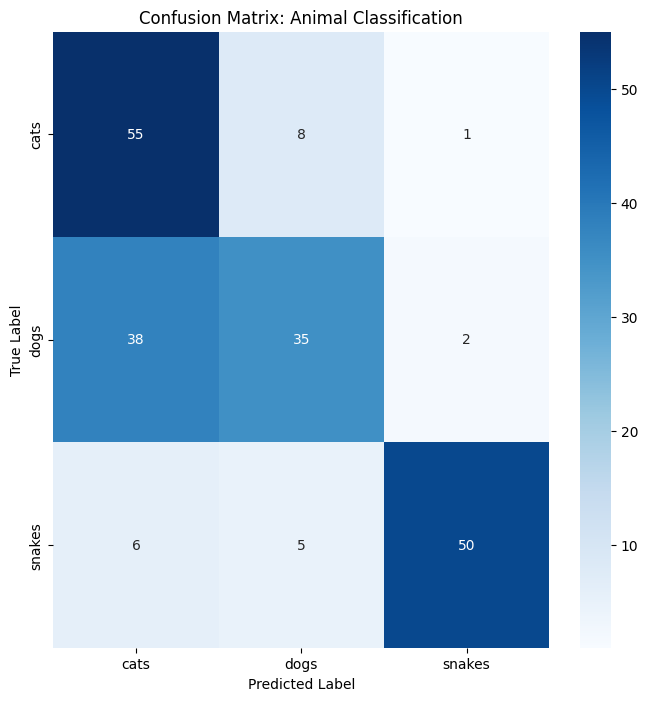

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

model_2.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for batch_idx, batch_data in enumerate(test_dataloader):
        # Move both to GPU/CPU at once
        inputs = batch_data['pixel_values']
        labels = batch_data['labels']
        outputs = model_2(inputs)
        preds=torch.argmax((torch.softmax(outputs, dim=1)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

#plot the confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, 
            annot=True,        # Show the numbers in the boxes
            fmt='d',           # Use integers (not scientific notation)
            cmap='Blues',      # Blue color scale
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Animal Classification')
plt.show()